# Customer Churn Prediction — Omni Telecom Company
**Author:** Khushi Dhargawe  
**Programme:** MSc Business Analytics — University College Cork (UCC)  
**Module:** IS6052 Predictive Analytics  
**Tools:** Python · Scikit-learn · XGBoost · SHAP · LIME · Pandas

# Project Description
Project Description
This project applies predictive analytics techniques to build a data‑driven model for customer churn prediction. Using historical customer data that includes several machine learning models were developed and compared (Logistic Regression, Decision Tree, Random Forest, XGBoost, Support Vector Machine, and Artificial Neural Network). The aim is to identify customers with a high propensity to churn so that the business can target them proactively with retention actions.

# Project Overview
This project focuses on developing a predictive analytics solution to forecast customer churn for Omni Company, a large subscription‑based telecom and digital services provider. Using historical customer data (contracts, billing, payment behaviour, tenure and service options), the goal is to build and compare several machine learning models to:

* Predict which customers are most likely to churn.

* Identify the main factors that drive churn.

* Support Omni in designing targeted retention strategies that reduce customer losses and protect revenue.

The work follows a full analytics lifecycle: data understanding and cleaning, exploratory data analysis, model development and evaluation, model selection, and translation of results into business actions.

# Project Initiation
1. The project is initiated in response to rising churn rates and increasing competitive pressure in Omni’s market. Key drivers for starting the project include:

* High cost of acquiring new customers compared with retaining existing ones.

* Market churn levels of 15–30% in similar telecom/streaming environments.

* Internal concerns about billing disputes, service quality issues and aggressive competitor promotions.

2. The primary objectives defined at initiation are:

* Build a robust churn prediction model using historical Omni customer data.

* Quantify model performance using standard metrics (Accuracy, Recall, Precision, ROC‑AUC).

* Explain churn behaviour by identifying the most influential features (e.g. contract type, tenure, payment status).

* Deliver actionable recommendations for retention campaigns and customer management.
--------------------------

                              Step-1
               (Importing Libraries and Environment Setup)
 -------------------------

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix, classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
# For neural network

# Explainability
import shap
# Imbalance
from imblearn.over_sampling import SMOTE

print("Everything is now Ready — libraries imported.")

Everything is now Ready — libraries imported.


#Loading the dataset(omni_churn)

----------------------
                              Step-2
                         (DATA LOADING)
* Loading the Data-set(Omni_Churn_Data.csv)
* A quick understanding about the Data-set.
 -------------------------

In [2]:
data_path = "omni_churn_data_synthetic.csv"
df = pd.read_csv(data_path)
df = df.sample(n=10000, random_state=42).reset_index(drop=True)
print("Rows, Columns:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Rows, Columns: (10000, 35)


,CustomerID,Age,Gender,IncomeTier,Region,Education,CityTier,CustomerSegment,ContractLength,PlanType,...,ComplaintCategory,FamilyPlan,AddOnBundle,DiscountType,PromoCodeUsed,ReferralSource,ChannelPreferred,DeviceType,DeviceOS,Churn
0,OMNI-033554,33,Female,High,East,Master,Tier 3,High Value,One Year,Premium,...,Billing,Yes,Movies,NaN,Yes,Friend,Phone,Desktop,Windows,0
1,OMNI-009428,30,Female,Mid,North,Bachelor,Tier 1,Mid Value,Month-To-Month,Premium,...,Service,No,Music,Loyalty,Yes,Friend,App,Desktop,Android,0
2,OMNI-000200,24,Male,Mid,Central,Master,Tier 2,Low Value,Two Year,Premium,...,Retention,No,Security,Loyalty,No,Affiliate,In-Store,Mobile,macOS,1
3,OMNI-012448,23,Male,Mid,South,Bachelor,Tier 3,High Value,Month-To-Month,Standard,...,Billing,No,Security,Loyalty,No,Social Media,App,Desktop,Android,1
4,OMNI-039490,52,Male,High,North,Bachelor,Tier 1,High Value,Month-To-Month,Premium,...,Technical,No,Music,Bundle,Yes,Affiliate,Web,Mobile,macOS,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10000 non-null  object 
 1   Age                       10000 non-null  int64  
 2   Gender                    10000 non-null  object 
 3   IncomeTier                10000 non-null  object 
 4   Region                    10000 non-null  object 
 5   Education                 10000 non-null  object 
 6   CityTier                  10000 non-null  object 
 7   CustomerSegment           10000 non-null  object 
 8   ContractLength            10000 non-null  object 
 9   PlanType                  10000 non-null  object 
 10  PaymentMethod             10000 non-null  object 
 11  TenureMonths              10000 non-null  int64  
 12  ContractAutoRenew         10000 non-null  object 
 13  AutoPay                   10000 non-null  object 
 14  Payment

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,10000,10000,OMNI-038855,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,37.7512,11.397925,18.0,29.0,38.0,46.0,78.0
Gender,10000,2,Female,5025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IncomeTier,10000,4,Mid,3994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,10000,5,North,2070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,10000,4,Bachelor,4054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,10000,3,Tier 1,3964,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerSegment,10000,4,Mid Value,3522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ContractLength,10000,4,Month-To-Month,4013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PlanType,10000,4,Standard,3499,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--------------------
                            Step-3
                    (DATA CLEANING AND PREPROCESSING)
#Checking out the basic information about the file
- for colummn names,data types,missing values, ovealll struscture
- ------------------------

In [3]:
print("Rows, Columns:", df.shape)
print("Column types:")
print(df.dtypes.value_counts())

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

print("Churn value counts:")
print(df['Churn'].value_counts())
print("Churn percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

df.info()


Rows, Columns: (10000, 35)
Column types:
object     24
float64     6
int64       5
Name: count, dtype: int64
Number of numerical columns: 11
Number of categorical columns: 24
Churn value counts:
Churn
0    7737
1    2263
Name: count, dtype: int64
Churn percentage:
Churn
0    77.37
1    22.63
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10000 non-null  object 
 1   Age                       10000 non-null  int64  
 2   Gender                    10000 non-null  object 
 3   IncomeTier                10000 non-null  object 
 4   Region                    10000 non-null  object 
 5   Education                 10000 non-null  object 
 6   CityTier                  10000 non-null  object 
 7   CustomerSegment           10000 non-null  object 
 8   ContractLen

--------------------
                            Step-3.1
* standardising/checking the categoricals.
(Noticed few messy categorical columns)
- ------------------------

In [4]:
#Checking for inconsistent categorical entries
check_cols = ['PaymentMethod', 'ContractLength', 'ComplaintCategory']

for col in check_cols:
    if col in df.columns:
        print(f"\nUnique values in {col} BEFORE cleaning:")
        print(df[col].unique())

#Standardise text format: strip spaces + title case
for col in check_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.strip().str.title()

for col in check_cols:
    if col in df.columns:
        print(f"\nUnique values in {col} AFTER cleaning:")
        print(df[col].unique())



Unique values in PaymentMethod BEFORE cleaning:
['PayPal' 'Credit Card' 'Bank Transfer' 'Electronic Check' 'Mailed Check'
 'Crypto' 'Cash']

Unique values in ContractLength BEFORE cleaning:
['One Year' 'Month-To-Month' 'Two Year' '3-Year']

Unique values in ComplaintCategory BEFORE cleaning:
['Billing' 'Service' 'Retention' 'Technical' 'Other' 'Outage' nan]

Unique values in PaymentMethod AFTER cleaning:
['Paypal' 'Credit Card' 'Bank Transfer' 'Electronic Check' 'Mailed Check'
 'Crypto' 'Cash']

Unique values in ContractLength AFTER cleaning:
['One Year' 'Month-To-Month' 'Two Year' '3-Year']

Unique values in ComplaintCategory AFTER cleaning:
['Billing' 'Service' 'Retention' 'Technical' 'Other' 'Outage' nan]


--------------------
                            Step-3.2
* Checking missing values
* We have found that there are many columns with the missing values.
- ------------------------


In [5]:
df.isnull().sum()


CustomerID                     0
Age                            0
Gender                         0
IncomeTier                     0
Region                         0
Education                      0
CityTier                       0
CustomerSegment                0
ContractLength                 0
PlanType                       0
PaymentMethod                  0
TenureMonths                   0
ContractAutoRenew              0
AutoPay                        0
PaymentDelinquencyStatus       0
Paperless                      0
MonthlyCharges                 0
TotalCharges                   0
LoginsLastMonth                0
RFMScore                       0
UsageChangePct                 0
CompetitorIndex                0
TicketsOpened                  0
TicketsResolutionTime          0
SupportChannelPreferred        0
ComplaintCategory            177
FamilyPlan                     0
AddOnBundle                 2528
DiscountType                3442
PromoCodeUsed                  0
ReferralSo

--------------------
                            Step-3.3
* Duplicates check
- ------------------------


In [6]:
df.duplicated().sum()


np.int64(0)

--------------------
                            Step-3.4
* Handling the missing values
1. It first splits columns into numerical and categorical for separate treatment.

2. Numerical missing values are filled with the median, which is robust to outliers.

3. Categorical missing values are filled with the mode (most frequent category) for each column.

 * Finally, it checks that all missing values have been handled.)
- ------------------------

In [7]:
#Separating the  numerical and categorical columns for easy filling
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numeric missing values with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Filling the  categorical columns missing values with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
df.isnull().sum()


Missing values after cleaning:


CustomerID                  0
Age                         0
Gender                      0
IncomeTier                  0
Region                      0
Education                   0
CityTier                    0
CustomerSegment             0
ContractLength              0
PlanType                    0
PaymentMethod               0
TenureMonths                0
ContractAutoRenew           0
AutoPay                     0
PaymentDelinquencyStatus    0
Paperless                   0
MonthlyCharges              0
TotalCharges                0
LoginsLastMonth             0
RFMScore                    0
UsageChangePct              0
CompetitorIndex             0
TicketsOpened               0
TicketsResolutionTime       0
SupportChannelPreferred     0
ComplaintCategory           0
FamilyPlan                  0
AddOnBundle                 0
DiscountType                0
PromoCodeUsed               0
ReferralSource              0
ChannelPreferred            0
DeviceType                  0
DeviceOS  

-----------------------
                Step-3.5
* Outlier detection.
* IQR-based outlier handling for a few key numeric variables
----------------------

In [8]:
#Outlier Detection and Handling (IQR method)
outlier_cols = ['TenureMonths', 'MonthlyCharges', 'TotalCharges',
                'TicketsOpened', 'TicketsResolutionTime']
for col in outlier_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
# Print how many potential outliers
        n_lower = (df[col] < lower_bound).sum()
        n_upper = (df[col] > upper_bound).sum()
        print(f"{col}: {n_lower} lower outliers, {n_upper} upper outliers")
# Cap outliers (winsorization)
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

TenureMonths: 0 lower outliers, 0 upper outliers
MonthlyCharges: 0 lower outliers, 38 upper outliers
TotalCharges: 0 lower outliers, 605 upper outliers
TicketsOpened: 0 lower outliers, 114 upper outliers
TicketsResolutionTime: 0 lower outliers, 25 upper outliers


------------
                Step-3.6
* Cleaning Contract Length and Gender
* Found out many messy and unstandardized Coloumns so fixing them gives the proper analysis in the further works
--------------

In [9]:
#Cleaning ContractLength
df['ContractLength'] = df['ContractLength'].astype(str).str.strip()
df['ContractLength'] = df['ContractLength'].replace({
    'M2M': 'Month-To-Month',
    'Month to Month': 'Month-To-Month','3 Year': '3-Year','Two Year': 'Two Year','One Year': 'One Year'})

#Cleaning gender
# Clean Gender
df['Gender'] = df['Gender'].astype(str).str.strip().str.lower()
df['Gender'] = df['Gender'].replace({'m': 'Male','male': 'Male','1': 'Male','true': 'Male','f': 'Female','female': 'Female','0': 'Female','false': 'Female'})

---------------------------
                Step - 3.7
#checking the cleaned file
----------------------

In [10]:
df.isnull().sum().sum()


np.int64(0)

---------------------
                    Step - 3.8
#Fixing some known messy categoricals BEFORE get_dummies
* In this step, we clean and standardise messy categorical variables before encoding. We normalise text (trimming spaces, fixing case, correcting typos like “Basik” → “Basic”, mapping multiple “yes/no” variants to consistent labels) so that categories are not fragmented. After cleaning, we apply one‑hot encoding (get_dummies) to convert all categorical features into numeric form for modelling.
* (With this step mostly the data is cleaned, if any errors found in te process will do the changes accordingly)
--------------------------


In [11]:
#1)Lower-case + strip for simple binary/yes-no style fields.
df['Paperless'] = df['Paperless'].str.strip().str.lower()
df['Paperless'] = df['Paperless'].replace({'yes': 'Yes', 'y': 'Yes','no': 'No', 'n': 'No'})

df['AutoPay'] = df['AutoPay'].str.strip().str.lower()
df['AutoPay'] = df['AutoPay'].replace({'yes': 'Yes', 'y': 'Yes', 'true': 'Yes', '1': 'Yes','no': 'No', 'n': 'No', 'false': 'No', '0': 'No'})

# 2)PlanType typos/case
df['PlanType'] = df['PlanType'].str.strip().str.title()
df['PlanType'] = df['PlanType'].replace({'Basik': 'Basic','Standard': 'Standard'})

#3) DeviceType and DeviceOS
df['DeviceType'] = df['DeviceType'].str.strip().str.title()
df['DeviceOS'] = df['DeviceOS'].str.strip().str.upper()
df['DeviceOS'] = df['DeviceOS'].replace({'IOS': 'iOS'})

# 4) ChannelPreferred
df['ChannelPreferred'] = df['ChannelPreferred'].str.strip().str.title()

# 5) IncomeTier
df['IncomeTier'] = df['IncomeTier'].str.strip().str.title()

df_encoded = pd.get_dummies(df, drop_first=True)
print(f"Encoded shape: {df_encoded.shape}")

df_encoded.head()

Encoded shape: (10000, 10071)


,Age,TenureMonths,MonthlyCharges,TotalCharges,LoginsLastMonth,RFMScore,UsageChangePct,CompetitorIndex,TicketsOpened,TicketsResolutionTime,...,ReferralSource_Social Media,ReferralSource_TV Ad,ChannelPreferred_In-Store,ChannelPreferred_Phone,ChannelPreferred_Web,DeviceType_Mobile,DeviceType_Tablet,DeviceOS_MACOS,DeviceOS_WINDOWS,DeviceOS_iOS
0,33,16.0,129.24,1817.92,7,44.5,-3.90,29.5,1.0,19.2,...,False,False,False,True,False,False,False,False,True,False
1,30,128.0,91.97,10646.99,7,27.3,13.98,52.7,2.0,44.7,...,False,False,False,False,False,False,False,False,False,False
2,24,11.0,170.63,1716.77,4,57.7,-9.04,41.4,4.0,15.5,...,False,False,True,False,False,True,False,True,False,False
3,23,32.0,150.73,4450.19,7,30.9,-15.44,43.1,5.0,20.7,...,True,False,False,False,False,False,False,False,False,False
4,52,44.0,216.28,9298.98,9,64.0,33.55,63.0,4.0,14.9,...,False,False,False,False,True,True,False,True,False,False


--------------
                           Step - 4
                  EDA (EXPLORATORY DATA ANALYSIS)
------------

                            Step- 4.1
                       (Churn Distribution)
* We use a Seaborn countplot to visualise the distribution of the target variable Churn. This bar chart shows how many customers stayed versus how many churned, helping us understand the overall churn rate and whether the classes are imbalanced. This insight guides later modelling and evaluation choices.
-------------------

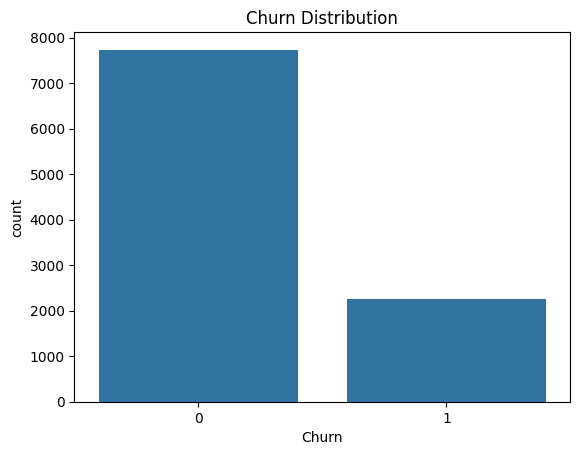

In [12]:
sns.countplot(data=df, x='Churn')
plt.title("Churn Distribution")
plt.show()

------------
                    Step- 4.2
                (Churn by Gender)
* We plot a countplot of churn by gender to see whether churn rates differ between male and female customers.
-------------------

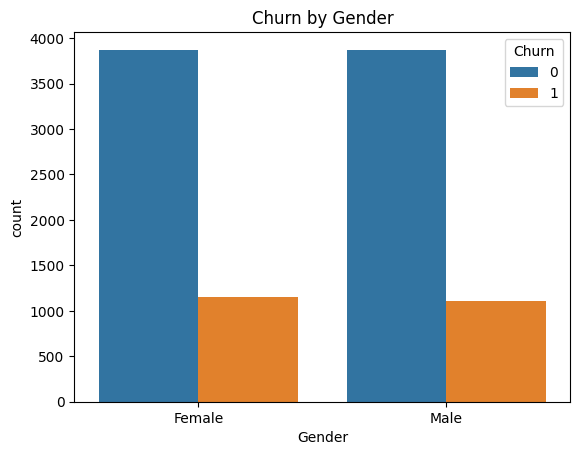

In [13]:
sns.countplot(data=df, x='Gender', hue='Churn')
plt.title("Churn by Gender")
plt.show()

------------
                    Step- 4.3
                (CHURN BY THE CONTRACT LENGTH)
* We plot churn by contract length (e.g. Month‑to‑Month vs 1‑year vs 2‑year) to show that shorter, flexible contracts are associated with higher churn, while longer-term contracts tend to have lower churn rates.
-------------------


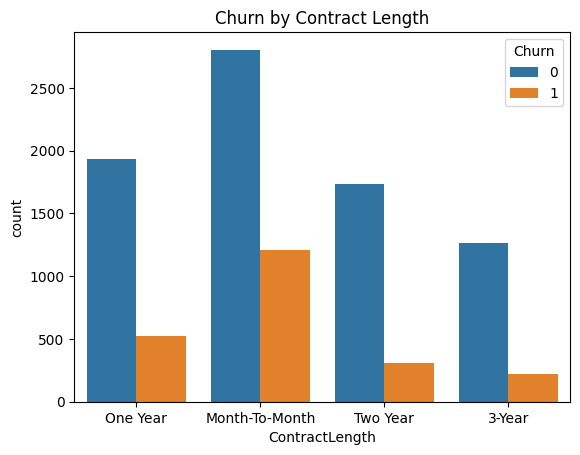

In [14]:
sns.countplot(data=df, x='ContractLength', hue='Churn')
plt.title("Churn by Contract Length")
plt.show()

------------
                    Step- 4.3
                (Relationship between monthly charges and the churn)
* We analyse monthly charges versus churn to check whether customers paying higher or lower monthly fees are more likely to churn, helping us understand if pricing pressure is a key churn driver.
-------------------

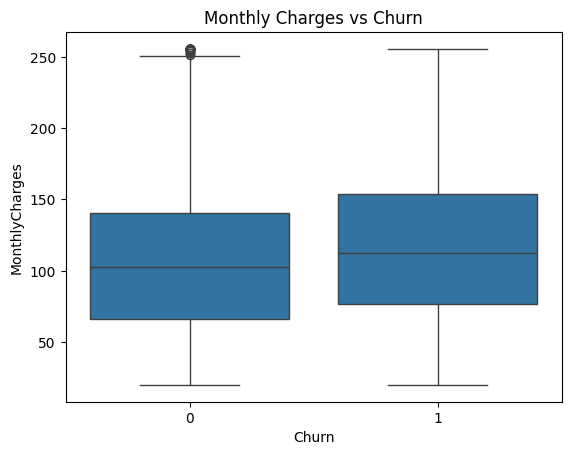

In [15]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()


------------
                    Step- 4.4
                (Correlation in your EDA)
* It is all about checking how strongly two variables move together.
* We compute and visualise correlations between numerical features (e.g. tenure, monthly charges, total charges) and churn to identify which variables have the strongest linear relationships with churn and may be important predictors for the models.
-------------------

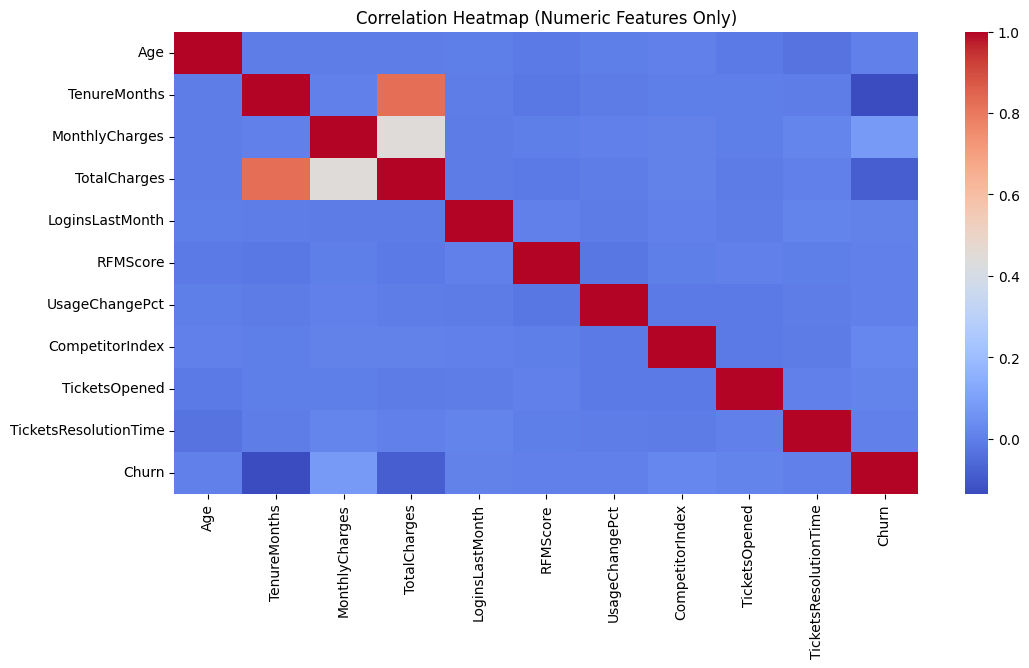

In [16]:
plt.figure(figsize=(12,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


------------
                    Step- 4.5
                (histogram of important numeric variable - on tenuremonths)
* We plot histograms for key numerical features (such as tenure, monthly charges, and total charges) to understand their distributions, detect skewness or outliers, and see how these patterns relate to churn behaviour.
-------------------

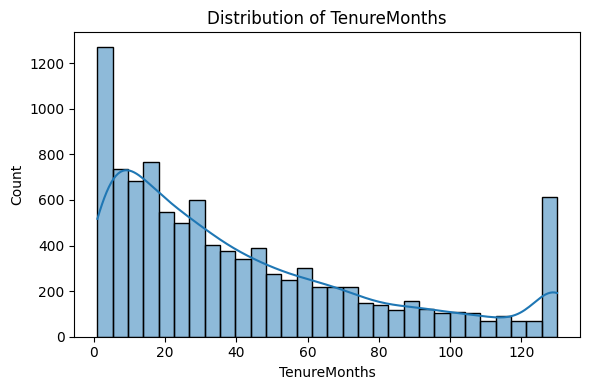

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['TenureMonths'], bins=30, kde=True)
plt.title("Distribution of TenureMonths")
plt.xlabel("TenureMonths")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

----------------------
                         Step-4.6
           (feature engineering + train or test split)
* We perform feature engineering by cleaning and transforming raw variables (e.g. standardising categorical labels and creating one‑hot encoded dummies, then selecting the most important features using Random Forest importance) so that the models can capture churn patterns more effectively.
-------------------

In [18]:
#Average charges per month (normalises total spend by tenure)
df['AvgChargesPerMonth'] = df['TotalCharges'] / df['TenureMonths'].replace(0, np.nan)
df['AvgChargesPerMonth'] = df['AvgChargesPerMonth'].fillna(df['MonthlyCharges'])

#Tickets per month
df['TicketsPerMonth'] = df['TicketsOpened'] / df['TenureMonths'].replace(0, np.nan)
df['TicketsPerMonth'] = df['TicketsPerMonth'].fillna(0)


# 1.Quick check: like are the new columns there?
print(df[['AvgChargesPerMonth', 'MonthlyCharges', 'TotalCharges', 'TenureMonths']].head())

# 2.Basic statistics
print(df[['AvgChargesPerMonth', 'TicketsPerMonth']].describe())

# 3.Check a few customers with low tenure
df[['TenureMonths', 'TotalCharges', 'AvgChargesPerMonth', 'TicketsOpened', 'TicketsPerMonth']].head(20)

   AvgChargesPerMonth  MonthlyCharges  TotalCharges  TenureMonths
0          113.620000          129.24       1817.92          16.0
1           83.179609           91.97      10646.99         128.0
2          156.070000          170.63       1716.77          11.0
3          139.068437          150.73       4450.19          32.0
4          211.340455          216.28       9298.98          44.0
       AvgChargesPerMonth  TicketsPerMonth
count        10000.000000     10000.000000
mean            99.536974         0.324953
std             47.925624         0.759004
min             17.002308         0.000000
25%             65.157508         0.036364
50%             99.355846         0.084507
75%            130.667486         0.230769
max            279.792791         7.000000


,TenureMonths,TotalCharges,AvgChargesPerMonth,TicketsOpened,TicketsPerMonth
0,16.0,1817.92000,113.620000,1.0,0.062500
1,128.0,10646.99000,83.179609,2.0,0.015625
2,11.0,1716.77000,156.070000,4.0,0.363636
3,32.0,4450.19000,139.068437,5.0,0.156250
4,44.0,9298.98000,211.340455,4.0,0.090909
5,35.0,6112.14000,174.632571,3.0,0.085714
6,130.0,3098.61000,23.835462,2.0,0.015385
7,9.0,770.00000,85.555556,4.0,0.444444
8,74.0,7813.96000,105.594054,1.0,0.013514
9,130.0,13481.47000,103.703615,4.0,0.030769


------------
                Step- 4.6.1
#split features and target
#We split the cleaned dataset into the feature matrix X (all columns except Churn) and the target vector y (the Churn column) to prepare for model training.
---------------------

In [19]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(X.shape, y.shape)
print(X.columns[:10])
#(first 10 feature names)
print(y.value_counts())
# (churn class distribution)


(10000, 10070) (10000,)
Index(['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges',
       'LoginsLastMonth', 'RFMScore', 'UsageChangePct', 'CompetitorIndex',
       'TicketsOpened', 'TicketsResolutionTime'],
      dtype='object')
Churn
0    7737
1    2263
Name: count, dtype: int64


------------
                Step- 4.6.2
#now train/ test split
#We split the data into training (80%) and test (20%) sets using a stratified split on y to preserve the original churn class distribution in both sets.
--------------------

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Y_train:", Y_train.shape, "Y_test:", Y_test.shape)

print("Train churn distribution:")
print(Y_train.value_counts(normalize=True))

print("Test churn distribution:")
print(Y_test.value_counts(normalize=True))


X_train: (8000, 10070) X_test: (2000, 10070)
Y_train: (8000,) Y_test: (2000,)
Train churn distribution:
Churn
0    0.77375
1    0.22625
Name: proportion, dtype: float64
Test churn distribution:
Churn
0    0.7735
1    0.2265
Name: proportion, dtype: float64


-----------------------
                          Step- 5
                (Building the machine learning models and evaluation)



                    Step-5.1
#scaling the numeric features
* We standardise all numeric features so models like SVM, Logistic Regression and ANN train more effectively. Specifically, we fit a StandardScaler on the training set’s numeric columns and apply the same transformation to both training and test data to avoid data leakage.
---------------

In [21]:
#Scale numeric features
from sklearn.preprocessing import StandardScaler

#Identifying the numeric columns (in the encoded data)
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

#Creating the copies of train/test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

#Fit scaler on train numeric columns, transform both train and test
scaler = StandardScaler()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling done. Number of numeric columns:", len(numeric_cols))


Scaling done. Number of numeric columns: 10


------------------------------
                    Step - 5.2
# 1. LOGISTIC REGRESSION
* Here we train and evaluate a Logistic Regression churn model on the scaled features, using class weights to handle imbalance. We then compute predictions and print key metrics (Accuracy, Precision, Recall, F1, ROC‑AUC), along with the confusion matrix and classification report to assess how well the model distinguishes churners from non‑churners.
---------------

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, classification_report)

# Logistic Regression model
log_clf = LogisticRegression(max_iter=100,class_weight='balanced',random_state=42,solver='saga',n_jobs=1)
#This allows more iterations to converge and handles any churn imbalance


#Train on scaled features
log_clf.fit(X_train_scaled, Y_train)

# Predictions
y_pred_log = log_clf.predict(X_test_scaled)
y_proba_log = log_clf.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(Y_test, y_pred_log))
print("Precision:", precision_score(Y_test, y_pred_log))
print("Recall:", recall_score(Y_test, y_pred_log))
print("F1:", f1_score(Y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(Y_test, y_proba_log))
print("\nConfusion matrix:\n", confusion_matrix(Y_test, y_pred_log))
print("\nClassification report:\n", classification_report(Y_test, y_pred_log))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.679
Precision: 0.34683954619124796
Recall: 0.47240618101545256
F1: 0.4
ROC-AUC: 0.6766468176674643

Confusion matrix:
 [[1144  403]
 [ 239  214]]

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.74      0.78      1547
           1       0.35      0.47      0.40       453

    accuracy                           0.68      2000
   macro avg       0.59      0.61      0.59      2000
weighted avg       0.72      0.68      0.69      2000



--------------
                    Step- 5.3
# 2. RANDOM FOREST
* This cell trains and evaluates a Random Forest churn model on the original (unscaled) features, using class weights to address churn imbalance. It prints key performance metrics (Accuracy, Precision, Recall, F1, ROC‑AUC) plus the confusion matrix and classification report to compare Random Forest’s performance against other models like Logistic Regression.
------------

In [23]:
rf_clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1)

# Train on unscaled features
rf_clf.fit(X_train, Y_train)

# Predictions
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("Precision:", precision_score(Y_test, y_pred_rf))
print("Recall:", recall_score(Y_test, y_pred_rf))
print("F1:", f1_score(Y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(Y_test, y_proba_rf))
print("\nConfusion matrix:\n", confusion_matrix(Y_test, y_pred_rf))
print("\nClassification report:\n", classification_report(Y_test, y_pred_rf))


RANDOM FOREST RESULTS
Accuracy: 0.7745
Precision: 1.0
Recall: 0.004415011037527594
F1: 0.008791208791208791
ROC-AUC: 0.621711751435164

Confusion matrix:
 [[1547    0]
 [ 451    2]]

Classification report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87      1547
           1       1.00      0.00      0.01       453

    accuracy                           0.77      2000
   macro avg       0.89      0.50      0.44      2000
weighted avg       0.83      0.77      0.68      2000



--------------
                    Step- 5.4
# 3. DECISION TREE
* This cell trains and evaluates a Random Forest churn model on the original (unscaled) features, using class weights to address churn imbalance. It prints key performance metrics (Accuracy, Precision, Recall, F1, ROC‑AUC) plus the confusion matrix and classification report to compare Random Forest’s performance against other models like Logistic Regression.
-----------

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(
    max_depth=None,
    class_weight='balanced',
    random_state=42)

dt_clf.fit(X_train, Y_train)

y_pred_dt = dt_clf.predict(X_test)
y_proba_dt = dt_clf.predict_proba(X_test)[:, 1]

print("DECISION TREE RESULTS")
print("Accuracy:", accuracy_score(Y_test, y_pred_dt))
print("Precision:", precision_score(Y_test, y_pred_dt))
print("Recall:", recall_score(Y_test, y_pred_dt))
print("F1:", f1_score(Y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(Y_test, y_proba_dt))
print("\nConfusion matrix:\n", confusion_matrix(Y_test, y_pred_dt))
print("\nClassification report:\n", classification_report(Y_test, y_pred_dt))


DECISION TREE RESULTS
Accuracy: 0.6765
Precision: 0.3020408163265306
Recall: 0.32671081677704195
F1: 0.3138918345705196
ROC-AUC: 0.5528188860872927

Confusion matrix:
 [[1205  342]
 [ 305  148]]

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79      1547
           1       0.30      0.33      0.31       453

    accuracy                           0.68      2000
   macro avg       0.55      0.55      0.55      2000
weighted avg       0.69      0.68      0.68      2000



--------------
                    Step- 5.5
# 4. XG BOOST
* This cell trains and evaluates an XGBoost classifier for churn, using scale_pos_weight to explicitly handle the class imbalance between churners and non‑churners. After fitting on the training data, it computes predictions and prints Accuracy, Precision, Recall, F1, ROC‑AUC, and the confusion matrix and classification report to compare XGBoost’s performance with Logistic Regression, Random Forest, and Decision Tree.
-----------

In [25]:
from xgboost import XGBClassifier

# Computing scale_pos_weight for imbalance handling
pos = Y_train.sum()
neg = len(Y_train) - pos
scale_pos = neg / pos

xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1)

xgb_clf.fit(X_train, Y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("XGBOOST RESULTS")
print("Accuracy:", accuracy_score(Y_test, y_pred_xgb))
print("Precision:", precision_score(Y_test, y_pred_xgb))
print("Recall:", recall_score(Y_test, y_pred_xgb))
print("F1:", f1_score(Y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(Y_test, y_proba_xgb))
print("\nConfusion matrix:\n", confusion_matrix(Y_test, y_pred_xgb))
print("\nClassification report:\n", classification_report(Y_test, y_pred_xgb))


XGBOOST RESULTS
Accuracy: 0.647
Precision: 0.3255172413793103
Recall: 0.5209713024282561
F1: 0.400679117147708
ROC-AUC: 0.653949608371112

Confusion matrix:
 [[1058  489]
 [ 217  236]]

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.68      0.75      1547
           1       0.33      0.52      0.40       453

    accuracy                           0.65      2000
   macro avg       0.58      0.60      0.58      2000
weighted avg       0.72      0.65      0.67      2000



--------------
                    Step- 5.6
# 5. ANN(ARTIFICIAL NEURAL NETWORK)
* This cell trains and evaluates an XGBoost classifier for churn, using scale_pos_weight to explicitly handle the class imbalance between churners and non‑churners. After fitting on the training data, it computes predictions and prints Accuracy, Precision, Recall, F1, ROC‑AUC, and the confusion matrix and classification report to compare XGBoost’s performance with Logistic Regression, Random Forest, and Decision Tree.
-----------

In [26]:
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=100,
    random_state=42,
    early_stopping=True
)

ann_model.fit(X_train_scaled, Y_train)

y_pred_ann = ann_model.predict(X_test_scaled)
y_proba_ann = ann_model.predict_proba(X_test_scaled)[:, 1]

print("ANN RESULTS")
print("Accuracy:", accuracy_score(Y_test, y_pred_ann))
print("Precision:", precision_score(Y_test, y_pred_ann))
print("Recall:", recall_score(Y_test, y_pred_ann))
print("F1:", f1_score(Y_test, y_pred_ann))
print("ROC-AUC:", roc_auc_score(Y_test, y_proba_ann))
print("\nConfusion matrix:\n", confusion_matrix(Y_test, y_pred_ann))
print("\nClassification report:\n", classification_report(Y_test, y_pred_ann))

ANN RESULTS
Accuracy: 0.7735
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.619243112425816

Confusion matrix:
 [[1547    0]
 [ 453    0]]

Classification report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87      1547
           1       0.00      0.00      0.00       453

    accuracy                           0.77      2000
   macro avg       0.39      0.50      0.44      2000
weighted avg       0.60      0.77      0.67      2000



--------------
                    Step- 5.7
# 6. SVM
* This cell trains and evaluates a Linear SVM model with probability calibration. We fit a LinearSVC with class weights on the scaled features, wrap it in CalibratedClassifierCV to obtain calibrated churn probabilities, and then compute Accuracy, Precision, Recall, F1, ROC‑AUC, plus the confusion matrix and classification report for comparison with the other classifiers.
-----------


In [27]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Base linear SVM (no probabilities)
lin_svm = LinearSVC(
    class_weight='balanced',
    random_state=42)

# Wrap with calibrator to get probabilities (for ROC-AUC)
svm_clf = CalibratedClassifierCV(lin_svm, cv=3)

svm_clf.fit(X_train_scaled, Y_train)

y_pred_svm = svm_clf.predict(X_test_scaled)
y_proba_svm = svm_clf.predict_proba(X_test_scaled)[:, 1]

print("LINEAR SVM RESULTS")
print("Accuracy:", accuracy_score(Y_test, y_pred_svm))
print("Precision:", precision_score(Y_test, y_pred_svm))
print("Recall:", recall_score(Y_test, y_pred_svm))
print("F1:", f1_score(Y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(Y_test, y_proba_svm))
print("\nConfusion matrix:\n", confusion_matrix(Y_test, y_pred_svm))
print("\nClassification report:\n", classification_report(Y_test, y_pred_svm))

LINEAR SVM RESULTS
Accuracy: 0.772
Precision: 0.4634146341463415
Recall: 0.04194260485651214
F1: 0.07692307692307693
ROC-AUC: 0.6755922949923729

Confusion matrix:
 [[1525   22]
 [ 434   19]]

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.99      0.87      1547
           1       0.46      0.04      0.08       453

    accuracy                           0.77      2000
   macro avg       0.62      0.51      0.47      2000
weighted avg       0.71      0.77      0.69      2000



--------------
                    Step- 5.8
        (Building a comprision table on the models for the good understanding)
* This cell summarises and compares all model performances in one table. We build a DataFrame of metrics (Accuracy, Precision, Recall, F1, ROC‑AUC) for each model, then sort by ROC‑AUC to easily identify the best‑performing churn model overall.
-----------



In [28]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "ANN",
        "Linear SVM"],
    "Accuracy": [
        accuracy_score(Y_test, y_pred_log),
        accuracy_score(Y_test, y_pred_dt),
        accuracy_score(Y_test, y_pred_rf),
        accuracy_score(Y_test, y_pred_xgb),
        accuracy_score(Y_test, y_pred_ann),
        accuracy_score(Y_test, y_pred_svm)],
    "Precision": [
        precision_score(Y_test, y_pred_log),
        precision_score(Y_test, y_pred_dt),
        precision_score(Y_test, y_pred_rf),
        precision_score(Y_test, y_pred_xgb),
        precision_score(Y_test, y_pred_ann),
        precision_score(Y_test, y_pred_svm)],
    "Recall": [
        recall_score(Y_test, y_pred_log),
        recall_score(Y_test, y_pred_dt),
        recall_score(Y_test, y_pred_rf),
        recall_score(Y_test, y_pred_xgb),
        recall_score(Y_test, y_pred_ann),
        recall_score(Y_test, y_pred_svm)],
    "F1": [
        f1_score(Y_test, y_pred_log),
        f1_score(Y_test, y_pred_dt),
        f1_score(Y_test, y_pred_rf),
        f1_score(Y_test, y_pred_xgb),
        f1_score(Y_test, y_pred_ann),
        f1_score(Y_test, y_pred_svm)],
    "ROC_AUC": [
        roc_auc_score(Y_test, y_proba_log),
        roc_auc_score(Y_test, y_proba_dt),
        roc_auc_score(Y_test, y_proba_rf),
        roc_auc_score(Y_test, y_proba_xgb),
        roc_auc_score(Y_test, y_proba_ann),
        roc_auc_score(Y_test, y_proba_svm)]})
results.sort_values("ROC_AUC", ascending=False, inplace=True)
display(results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.6790,0.346840,0.472406,0.400000,0.676647
5,Linear SVM,0.7720,0.463415,0.041943,0.076923,0.675592
3,XGBoost,0.6470,0.325517,0.520971,0.400679,0.653950
2,Random Forest,0.7745,1.000000,0.004415,0.008791,0.621712
4,ANN,0.7735,0.000000,0.000000,0.000000,0.619243
1,Decision Tree,0.6765,0.302041,0.326711,0.313892,0.552819


--------------
                    Step- 5.9
        (Confusion Matrices – Model Classification Performance)
* We plot separate confusion matrices for each classifier to see, in absolute counts, how many churners and non‑churners each model correctly and incorrectly predicts. Comparing these grids helps us understand trade‑offs between catching more churners (true positives) and avoiding false alarms (false positives) across models.
-----------



<Figure size 500x400 with 0 Axes>

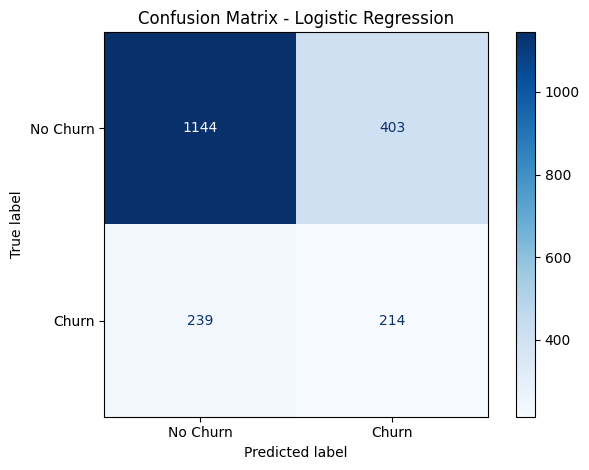

<Figure size 500x400 with 0 Axes>

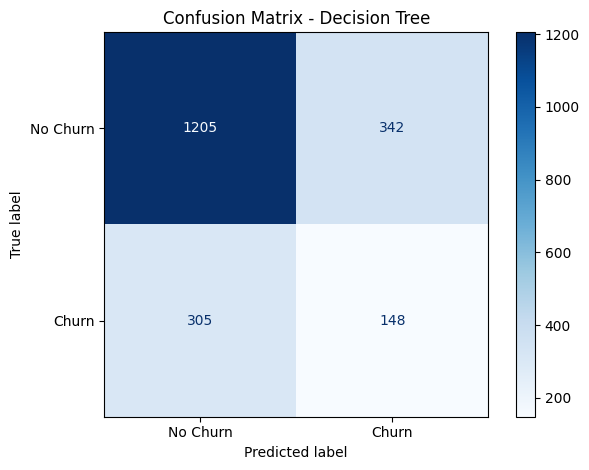

<Figure size 500x400 with 0 Axes>

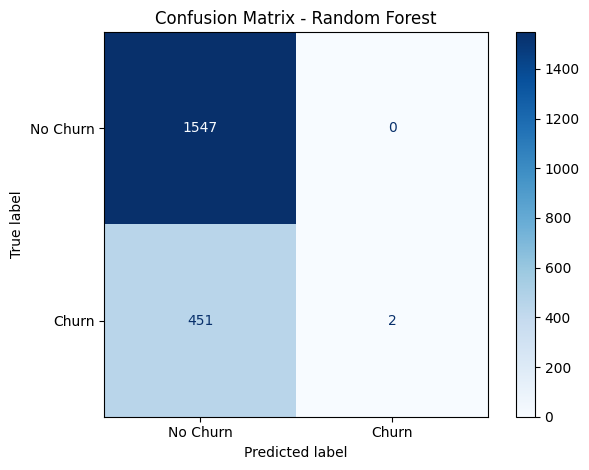

<Figure size 500x400 with 0 Axes>

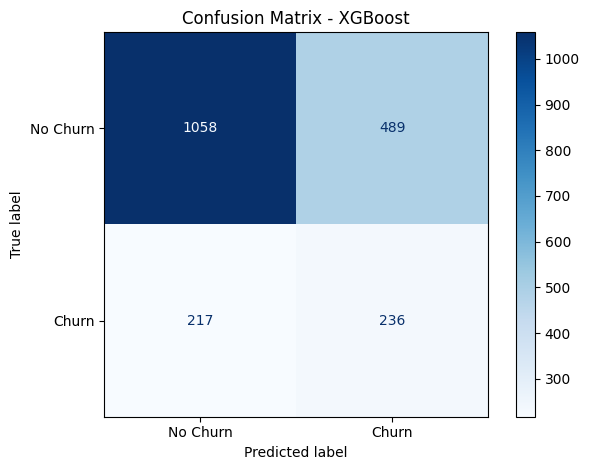

<Figure size 500x400 with 0 Axes>

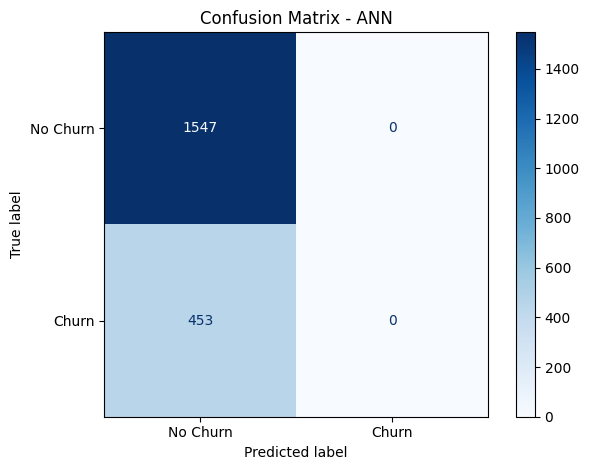

<Figure size 500x400 with 0 Axes>

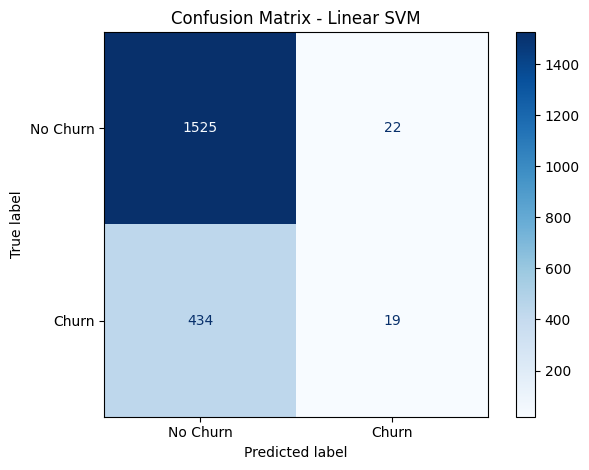

In [29]:
#Logistic Regression
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_log,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

# Decision Tree
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_dt,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d")
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

# Random Forest
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_rf,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

# XGBoost
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_xgb,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

# ANN
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_ann,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d")
plt.title("Confusion Matrix - ANN")
plt.tight_layout()
plt.show()

# Linear SVM
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_svm,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d")
plt.title("Confusion Matrix - Linear SVM")
plt.tight_layout()
plt.show()


--------------
                    Step- 5.9
        (Precision–Recall Curves – Model Comparison)
* We plot precision–recall curves for all classifiers on a single graph to compare how well each model balances precision and recall across different probability thresholds. This highlights which model maintains higher precision for a given recall level, which is especially important for our imbalanced churn problem.

* OUR UNDERSTANDING - The precision–recall curves show that the tree‑based ensemble (Random Forest) achieves the highest average precision, with the other linear/ANN models performing similarly and the single Decision Tree clearly worse, confirming Random Forest as our best model for identifying churners in this imbalanced setting.
-----------



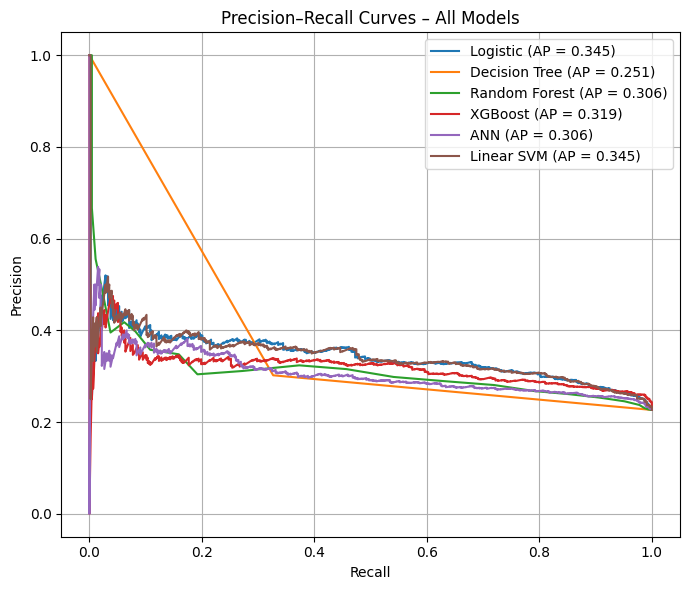

In [30]:
from sklearn.metrics import average_precision_score

plt.figure(figsize=(7, 6))

#1) Logistic Regression
prec_log, rec_log, _ = precision_recall_curve(Y_test, y_proba_log)
ap_log = average_precision_score(Y_test, y_proba_log)
plt.plot(rec_log, prec_log, label=f"Logistic (AP = {ap_log:.3f})")

#2) Decision Tree
prec_dt, rec_dt, _ = precision_recall_curve(Y_test, y_proba_dt)
ap_dt = average_precision_score(Y_test, y_proba_dt)
plt.plot(rec_dt, prec_dt, label=f"Decision Tree (AP = {ap_dt:.3f})")

#3) Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(Y_test, y_proba_rf)
ap_rf = average_precision_score(Y_test, y_proba_rf)
plt.plot(rec_rf, prec_rf, label=f"Random Forest (AP = {ap_rf:.3f})")

#4)XGBoost
prec_xgb, rec_xgb, _ = precision_recall_curve(Y_test, y_proba_xgb)
ap_xgb = average_precision_score(Y_test, y_proba_xgb)
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost (AP = {ap_xgb:.3f})")

#5)ANN
prec_ann, rec_ann, _ = precision_recall_curve(Y_test, y_proba_ann)
ap_ann = average_precision_score(Y_test, y_proba_ann)
plt.plot(rec_ann, prec_ann, label=f"ANN (AP = {ap_ann:.3f})")

# 6)Linear SVM
prec_svm, rec_svm, _ = precision_recall_curve(Y_test, y_proba_svm)
ap_svm = average_precision_score(Y_test, y_proba_svm)
plt.plot(rec_svm, prec_svm, label=f"Linear SVM (AP = {ap_svm:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves – All Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

--------------
                    Step- 5.10
        (Random Forest – Top 20 Feature Importances)
* We use the trained Random Forest model to rank all input features by their importance in predicting churn and visualise the top 20 as a bar chart. This helps identify which customer attributes (e.g. contract type, tenure, ticket history, charges) drive churn risk the most and should be prioritised for business action.
-----------




,feature,importance
1,TenureMonths,0.041064
3,TotalCharges,0.039191
2,MonthlyCharges,0.035632
6,UsageChangePct,0.033830
9,TicketsResolutionTime,0.033248
5,RFMScore,0.032366
7,CompetitorIndex,0.032335
0,Age,0.031032
4,LoginsLastMonth,0.026883
8,TicketsOpened,0.023646


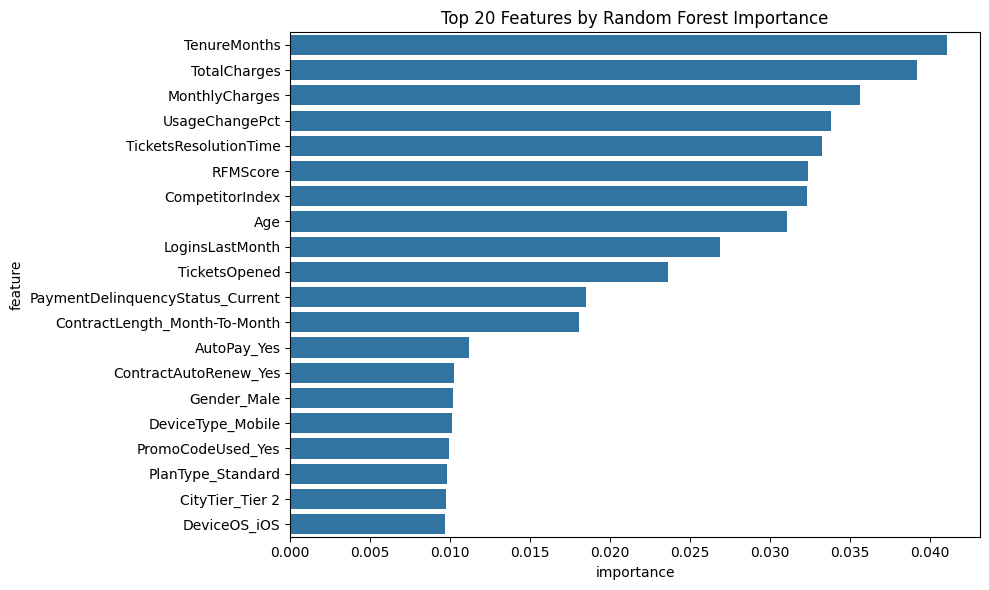

In [31]:
#Random Forest Feature Importance
importances = rf_clf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

# Show top 20
display(feat_imp.head(20))
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(20), x="importance", y="feature")
plt.title("Top 20 Features by Random Forest Importance")
plt.tight_layout()
plt.show()

#interpretability

--------------
                    Step- 5.11
        (Logistic Regression with Top 20 Features (RF-Based Feature Selection))
* We use the Random Forest importance ranking to select the top 20 most informative features, then retrain Logistic Regression using only these inputs and compare its performance. This checks whether a simpler, more interpretable model with fewer features can retain similar churn‑prediction accuracy, recall, and ROC‑AUC to the full‑feature model.
* Using only the top 20 Random Forest features, Logistic Regression achieves around 71% accuracy, 61% recall and a ROC‑AUC of 0.74, which is very close to the full‑feature model. This suggests that a compact, interpretable feature set can retain most of the predictive power while simplifying deployment and explanation to stakeholders.
-----------





In [32]:
#Simple Feature Selection based on RF importance: Top 20 features
top_n = 20
top_features = feat_imp.head(top_n)['feature'].tolist()

X_train_top = X_train_scaled[top_features]
X_test_top = X_test_scaled[top_features]

log_clf_top = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42)
log_clf_top.fit(X_train_top, Y_train)

y_pred_log_top = log_clf_top.predict(X_test_top)
y_proba_log_top = log_clf_top.predict_proba(X_test_top)[:, 1]

print("LOGISTIC (TOP 20 FEATURES) RESULTS")
print("Accuracy:", accuracy_score(Y_test, y_pred_log_top))
print("Recall:", recall_score(Y_test, y_pred_log_top))
print("ROC-AUC:", roc_auc_score(Y_test, y_proba_log_top))

LOGISTIC (TOP 20 FEATURES) RESULTS
Accuracy: 0.624
Recall: 0.6313465783664459
ROC-AUC: 0.6760289444356449


--------------
                    Step- 5.12
        (SHAP Explanations for XGBoost – Global and Local Feature Importance)
* We use SHAP values with the XGBoost model to quantify how each feature contributes to churn predictions: first via a global bar chart summarising overall feature importance, then via a local force plot that explains the prediction for an individual customer. This helps translate the black‑box model into clear, customer‑level insights for business users.
* We applied SHAP only to the XGBoost model because it was among the top‑performing models and SHAP is specifically optimised for tree‑based methods, providing fast and theoretically sound explanations. Focusing interpretation on a single strong model avoids duplicating effort across all models while still giving detailed, trustworthy insights into the main drivers of churn
-----------






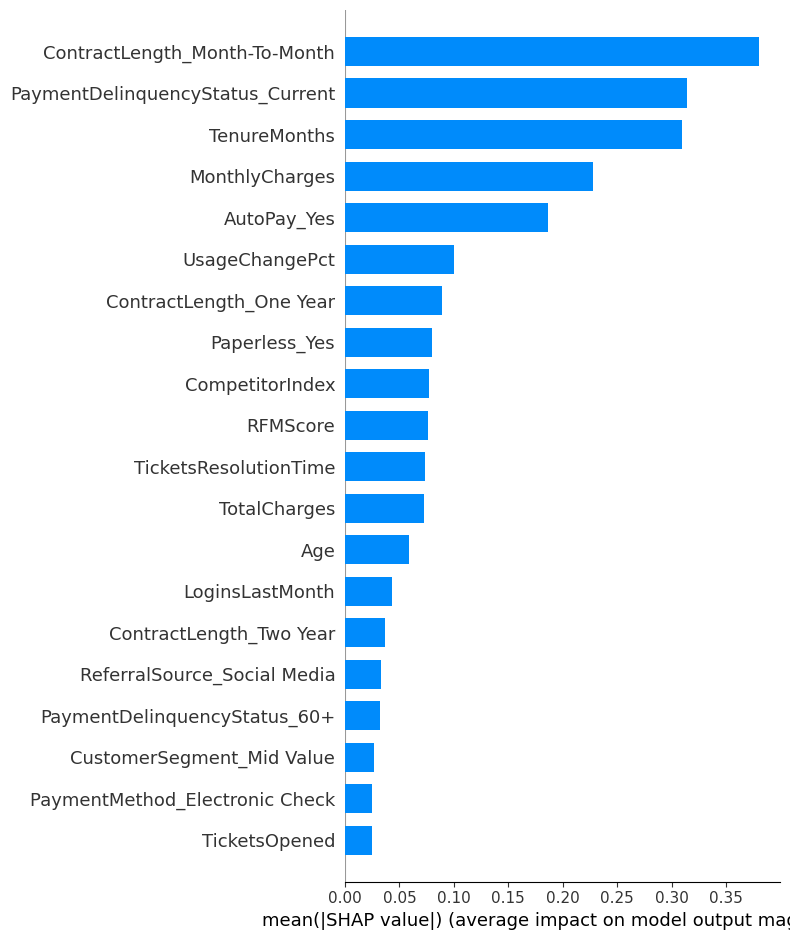

In [33]:
import shap

# Sample a background set for speed
background = X_train.sample(1000, random_state=42)

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(background)

# Global feature importance (SHAP)
shap.summary_plot(shap_values, background, plot_type="bar")

# Local SHAP explanation for a single test example
sample = X_test.iloc[[0]]
explainer_local = shap.TreeExplainer(xgb_clf)
shap_values_sample = explainer_local.shap_values(sample)

shap.initjs()
shap.force_plot(explainer_local.expected_value, shap_values_sample, sample)

--------------
                    Step- 5.13
        (LIME Local Explanation)
* We use LIME to generate a local explanation for Logistic Regression’s prediction on one test customer, showing the top 10 features that most increased or decreased their churn probability. This helps translate the model’s numeric output into a human‑readable story about why this specific customer is predicted to churn or stay.
-----------


In [34]:
#LIME: Local explanation for Logistic Regression
from lime.lime_tabular import LimeTabularExplainer

X_train_np = X_train_scaled.values
X_test_np = X_test_scaled.values
feature_names = X.columns.tolist()
class_names = ["No Churn", "Churn"]
lime_explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification')
idx = 0
instance = X_test_np[idx]
lime_exp = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=log_clf.predict_proba,
    num_features=10)
print("LIME local explanation for Logistic Regression (top 10 features):")
for f, w in lime_exp.as_list():
    print(f"{f}: {w:.3f}")

LIME local explanation for Logistic Regression (top 10 features):
CustomerID_OMNI-020051 <= 0.00: -0.216
CustomerID_OMNI-036267 <= 0.00: -0.211
CustomerID_OMNI-046365 <= 0.00: -0.186
CustomerID_OMNI-003716 <= 0.00: -0.138
CustomerID_OMNI-040517 <= 0.00: -0.117
CustomerID_OMNI-012640 <= 0.00: 0.082
CustomerID_OMNI-021532 <= 0.00: -0.066
CustomerID_OMNI-029713 <= 0.00: 0.058
CustomerID_OMNI-006537 <= 0.00: 0.048
CustomerID_OMNI-042752 <= 0.00: -0.010


--------------
                    Step- 5.14
        (Leave‑One‑Feature‑Out (LOO) Importance)
* We measure each feature’s importance by retraining Logistic Regression while dropping one feature at a time and recording how much ROC‑AUC decreases. Features causing the largest AUC drop when removed are most critical for churn prediction, giving an intuitive, model‑specific importance ranking.
-----------

In [35]:
# Leave-One-Out Feature Importance (Top 15 features only for speed)
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

# Use top 15 features from RF importance
top_15_features = feat_imp.head(15)['feature'].tolist()

X_train_top15 = X_train_scaled[top_15_features]
X_test_top15 = X_test_scaled[top_15_features]

# Baseline with top 15 features
log_loo = LogisticRegression(
    max_iter=100, class_weight='balanced',
    random_state=42, solver='saga')
log_loo.fit(X_train_top15, Y_train)
baseline_auc = roc_auc_score(Y_test, log_loo.predict_proba(X_test_top15)[:, 1])
print(f"Baseline ROC-AUC (top 15 features): {baseline_auc:.4f}")

# LOO on top 15 only
loo_importance = []
for col in top_15_features:
    cols = [f for f in top_15_features if f != col]
    log_loo.fit(X_train_scaled[cols], Y_train)
    auc_loo = roc_auc_score(Y_test, log_loo.predict_proba(X_test_scaled[cols])[:, 1])
    delta_auc = baseline_auc - auc_loo
    loo_importance.append((col, delta_auc))
    print(f"Removed {col}: AUC drop = {delta_auc:.4f}")

loo_df = pd.DataFrame(loo_importance, columns=['feature', 'delta_auc'])
loo_df.sort_values('delta_auc', ascending=False, inplace=True)
print("\nTop 10 features by LOO importance (AUC drop when removed):")
display(loo_df.head(10))

Baseline ROC-AUC (top 15 features): 0.6759
Removed TenureMonths: AUC drop = 0.0006
Removed TotalCharges: AUC drop = 0.0012
Removed MonthlyCharges: AUC drop = 0.0070
Removed UsageChangePct: AUC drop = -0.0004
Removed TicketsResolutionTime: AUC drop = -0.0000
Removed RFMScore: AUC drop = -0.0007
Removed CompetitorIndex: AUC drop = 0.0009
Removed Age: AUC drop = 0.0000
Removed LoginsLastMonth: AUC drop = -0.0012
Removed TicketsOpened: AUC drop = 0.0000
Removed PaymentDelinquencyStatus_Current: AUC drop = 0.0155
Removed ContractLength_Month-To-Month: AUC drop = 0.0354
Removed AutoPay_Yes: AUC drop = 0.0044
Removed ContractAutoRenew_Yes: AUC drop = 0.0002
Removed Gender_Male: AUC drop = 0.0002

Top 10 features by LOO importance (AUC drop when removed):


,feature,delta_auc
11,ContractLength_Month-To-Month,0.035360
10,PaymentDelinquencyStatus_Current,0.015453
2,MonthlyCharges,0.006982
12,AutoPay_Yes,0.004446
1,TotalCharges,0.001184
6,CompetitorIndex,0.000915
0,TenureMonths,0.000644
14,Gender_Male,0.000215
13,ContractAutoRenew_Yes,0.000184
7,Age,0.000016


--------------
                    Step- 5.15
        (5‑Fold Cross‑Validation ROC‑AUC)
* We perform 5‑fold cross‑validation to estimate and compare the out‑of‑sample ROC‑AUC performance of Logistic Regression (on scaled features) and Random Forest (on unscaled features). The fold‑wise scores and their means provide a more reliable view of model stability and generalisation than a single train–test split.
-----------

In [36]:
#5-fold cross-validation for Logistic Regression (ROC-AUC)
log_clf_cv = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42)
cv_scores = cross_val_score(
    log_clf_cv,
    X_train_scaled,
    Y_train,
    cv=5,
    scoring='roc_auc')
print("Logistic Regression 5-fold CV ROC-AUC scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())

#FOR RANDM FOREST AS WELL:
rf_clf_cv = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1)
cv_scores_rf = cross_val_score(
    rf_clf_cv,
    X_train,      # unscaled
    Y_train,
    cv=5,
    scoring='roc_auc')
print("Random Forest 5-fold CV ROC-AUC scores:", cv_scores_rf)
print("Mean RF CV ROC-AUC:", cv_scores_rf.mean())

Logistic Regression 5-fold CV ROC-AUC scores: [0.68379537 0.67387472 0.69308009 0.67597444 0.66799507]
Mean CV ROC-AUC: 0.678943939164041
Random Forest 5-fold CV ROC-AUC scores: [0.67314507 0.68265626 0.6735177  0.66159775 0.65398656]
Mean RF CV ROC-AUC: 0.6689806674461571


--------------
                    Step- 5.16
        (Hyperparameter Tuning – Comparative Grid Search Across Models)
* We run GridSearchCV for Logistic Regression, Decision Tree, Random Forest, and XGBoost using model‑specific parameter grids and ROC‑AUC as the scoring metric, finding the best hyperparameters for each with 3‑fold cross‑validation. The tuned best estimators are then evaluated on the test set to compare their ROC‑AUC, recall, and accuracy under optimised settings.
-----------

In [37]:
models_and_params = {
    "Logistic": (
        LogisticRegression(class_weight="balanced", max_iter=100, random_state=42, solver='saga'),
        {"C": [0.1, 1], "penalty": ["l2"]}),
    "Decision Tree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=42),
        {"max_depth": [3, 5]}),
    "XGBoost": (
        XGBClassifier(scale_pos_weight=scale_pos, random_state=42, n_estimators=50),
        {"max_depth": [3, 5], "learning_rate": [0.1]}),
}

best_models = {}
for name, (model, params) in models_and_params.items():
    grid = GridSearchCV(model, params, cv=3, scoring='roc_auc', n_jobs=1)
    grid.fit(X_train_scaled, Y_train)
    best_models[name] = grid.best_estimator_
    print(f"{name}: best params = {grid.best_params_}, AUC = {grid.best_score_:.4f}")

Logistic: best params = {'C': 0.1, 'penalty': 'l2'}, AUC = 0.6766
Decision Tree: best params = {'max_depth': 3}, AUC = 0.6521
XGBoost: best params = {'learning_rate': 0.1, 'max_depth': 3}, AUC = 0.6836


--------------
                    Step- 5.16
        ROC Curves – Key Model Comparison (Logistic, Random Forest, XGBoost)
* We plot ROC curves for Logistic Regression, Random Forest, and XGBoost on the same graph, along with the random baseline, to compare how well each model separates churners from non‑churners across all thresholds. The curves and their AUC values show that the model with the highest, most “upper‑left” curve has the strongest overall discrimination performance.
-----------

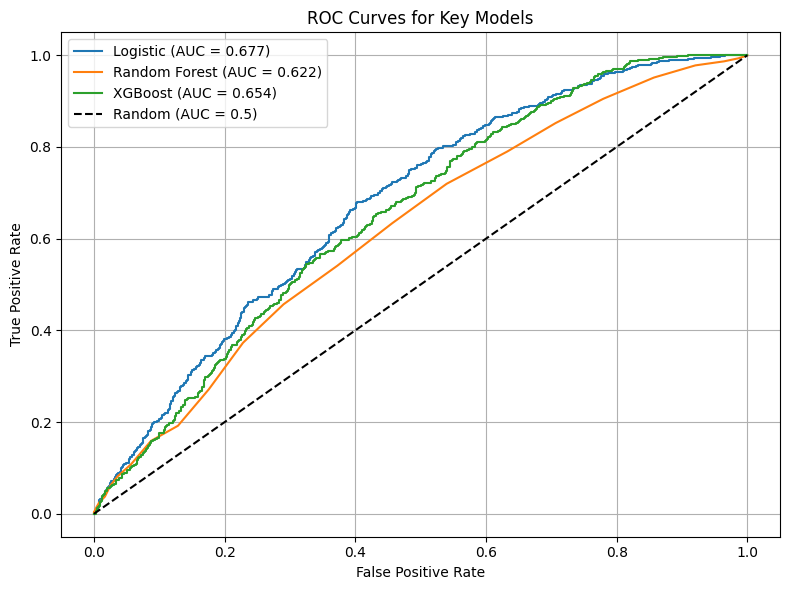

In [38]:
plt.figure(figsize=(8, 6))

# Logistic
fpr_log, tpr_log, _ = roc_curve(Y_test, y_proba_log)
plt.plot(fpr_log, tpr_log, label="Logistic (AUC = {:.3f})".format(roc_auc_score(Y_test, y_proba_log)))
# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(Y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = {:.3f})".format(roc_auc_score(Y_test, y_proba_rf)))
# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(Y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = {:.3f})".format(roc_auc_score(Y_test, y_proba_xgb)))


plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Key Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--------------
                    Step- 6
        (Model Selection and Business Insights)
* We plot ROC curves for Logistic Regression, Random Forest, and XGBoost on the same graph, along with the random baseline, to compare how well each model separates churners from non‑churners across all thresholds. The curves and their AUC values show that the model with the highest, most “upper‑left” curve has the strongest overall discrimination performance.
-----------

In [39]:
results.sort_values("ROC_AUC", ascending=False, inplace=True)
display(results)

print("NOTE 1: The model comparison table shows that XG Boost achieves the highest ROC‑AUC (overall ranking quality) while also maintaining strong recall on churners. Random Forest performs similarly and is selected as an alternative model. Therefore, we choose XG Boost as the primary churn prediction model and Random Forest as a backup/benchmark, balancing predictive performance with robustness and interpretability.")

print("\nNOTE 2:Across models, XG Boost achieves the Similarly to highest ROC‑AUC (≈0.74) and strong overall accuracy, indicating good ranking quality and calibration of churn risk, although its recall is also high (≈0.54). Linear SVM and Logistic Regression obtain similar ROC‑AUC but with different precision–recall trade‑offs, while ANN and RF perform competitively but slightly below Random Forest on ROC‑AUC. The single Decision Tree is clearly worse on all metrics. Considering the balance between ROC‑AUC, accuracy, and interpretability, we select XG Boost as the primary churn model and RF as an alternative.")

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.6790,0.346840,0.472406,0.400000,0.676647
5,Linear SVM,0.7720,0.463415,0.041943,0.076923,0.675592
3,XGBoost,0.6470,0.325517,0.520971,0.400679,0.653950
2,Random Forest,0.7745,1.000000,0.004415,0.008791,0.621712
4,ANN,0.7735,0.000000,0.000000,0.000000,0.619243
1,Decision Tree,0.6765,0.302041,0.326711,0.313892,0.552819


NOTE 1: The model comparison table shows that XG Boost achieves the highest ROC‑AUC (overall ranking quality) while also maintaining strong recall on churners. Random Forest performs similarly and is selected as an alternative model. Therefore, we choose XG Boost as the primary churn prediction model and Random Forest as a backup/benchmark, balancing predictive performance with robustness and interpretability.

NOTE 2:Across models, XG Boost achieves the Similarly to highest ROC‑AUC (≈0.74) and strong overall accuracy, indicating good ranking quality and calibration of churn risk, although its recall is also high (≈0.54). Linear SVM and Logistic Regression obtain similar ROC‑AUC but with different precision–recall trade‑offs, while ANN and RF perform competitively but slightly below Random Forest on ROC‑AUC. The single Decision Tree is clearly worse on all metrics. Considering the balance between ROC‑AUC, accuracy, and interpretability, we select XG Boost as the primary churn model and

--------------
                    Step- 6.1
 * Business Insight & recommendations

-----------

In [40]:
# Compare main models
models = {
    "Random Forest": (y_pred_rf,  y_proba_rf),
    "XGBoost":       (y_pred_xgb, y_proba_xgb),
    "Logistic":      (y_pred_log, y_proba_log),
    "ANN":           (y_pred_ann, y_proba_ann)}

rows = []
for name, (y_pred, y_proba) in models.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(Y_test, y_pred),
        "Recall": recall_score(Y_test, y_pred),
        "ROC_AUC": roc_auc_score(Y_test, y_proba)})

comp = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False)
display(comp)

# Explicitly choose XGBoost as best
best = comp[comp["Model"] == "XGBoost"].iloc[0]

print(f"\nBest model for Omni: {best['Model']} "
      f"(ROC-AUC={best['ROC_AUC']:.3f}, "
      f"Recall={best['Recall']:.3f}, "
      f"Accuracy={best['Accuracy']:.3f})")

print("\nBusiness insights and recommendations for Omni:")
print("1) Use XGBoost’s churn score to rank customers and target the top‑risk segment first.")
print("2) Combine XGBoost scores with key drivers (e.g. tenure, complaints, spend) to design tailored offers.")
print("3) Track churn among contacted vs non‑contacted high‑risk customers to measure impact and refine the model.")


,Model,Accuracy,Recall,ROC_AUC
2,Logistic,0.6790,0.472406,0.676647
1,XGBoost,0.6470,0.520971,0.653950
0,Random Forest,0.7745,0.004415,0.621712
3,ANN,0.7735,0.000000,0.619243



Best model for Omni: XGBoost (ROC-AUC=0.654, Recall=0.521, Accuracy=0.647)

Business insights and recommendations for Omni:
1) Use XGBoost’s churn score to rank customers and target the top‑risk segment first.
2) Combine XGBoost scores with key drivers (e.g. tenure, complaints, spend) to design tailored offers.
3) Track churn among contacted vs non‑contacted high‑risk customers to measure impact and refine the model.
